<a href="https://colab.research.google.com/github/Prashant230531/AI_FinalYear/blob/main/Prashant_Sharma_week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

In [8]:
!ls "/content/drive/MyDrive/"

'2330812_SachinGyawali (1) (1).ipynb'
'2330812_SachinGyawali (1).ipynb'
'2417367_SujalaAdhikari_FinalAssessment (1).ipynb'
 2417736_Prashant_Sharma1.ipynb
'6CS005 Week 6 Workshop.gdoc'
'A24 BCS Schedule L5CG19.gdoc'
 AI
'AI Proposal'
'Attendance Report - Prashant Sharma (null).pdf'
 BIGDATASEM6.ipynb
'BigData_Week_1 (1).ipynb'
'Blank Quiz.gform'
 blood_donation_feature_details.docx
 Classroom
 Cloud
'Colab Notebooks'
 Complex
'Copy of Building a User Registration System using PHP and JSON.pdf'
'Copy of MoSCoW Prioritization.gsheet'
'Copy of Risk Register for Collaborative.gsheet'
'Copy of Sample Login Test Case.xlsx'
'Copy of WS02_MNIST_Digit_Classification_with_Logistic_Regression_Worksheet_Starter_Code.ipynb'
 dataset_31_credit-g.arff
 diabetes.1.csv
 diabetes.csv
'Enrollment and Module Registration.pptx (2) (2) (1).gdoc'
'Enrollment and Module Registration.pptx (2) (2) (1).pdf'
'FOC week 10'
 FYP
'Google AI Studio'
 Java
'JAVA Sem 3'
 Java_week
'Lec - 01 - {Final} - Getting Started 

In [11]:
!ls /content/drive/MyDrive/AI/

'Copy of devnagari digit.zip'
'Flower Classification-20260416T164853Z-3-001'
 FruitinAmazon
 mnist_0_and_1.csv
 mnist_3_and_5.csv
 prashant_devanagari_model.h5
 Prashant_Sharma_Worksheet0.ipynb
'Screenshot 2025-12-16 120214.png'
 Workshop_1_Prashant_Sharma_2417736.ipynb


Identifying dataset classes

In [12]:
import os

base_dir = "/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon"

for root, dirs, files in os.walk(base_dir):
    for file in files:
        print(os.path.join(root, file))

/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon/train/tucuma/images (1).jpeg
/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon/train/tucuma/images (7).jpeg
/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon/train/tucuma/images (3).jpeg
/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon/train/tucuma/download (9).jpeg
/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon/train/tucuma/images (8).jpeg
/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon/train/tucuma/download.jpeg
/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon/train/tucuma/images (5).jpeg
/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon/train/tucuma/download (3).jpeg
/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon/train/tucuma/images (2).jpeg
/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon/train/tucuma/images (6).jpeg
/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon/train/tucuma/download (6).jpeg
/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon/train/tucuma/images.jpeg
/con

In [14]:
import os

base_dir = "/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon"
train_dir = os.path.join(base_dir, "train")

# getting the class name/subdirectories
class_names = sorted(os.listdir(train_dir))

print("Dataset folders:", os.listdir(base_dir))

if not class_names:
    print("No class directories found in the train folder!!")
else:
    print("Class names:", class_names)



Dataset folders: ['train', 'test']
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


Visualizing sample images

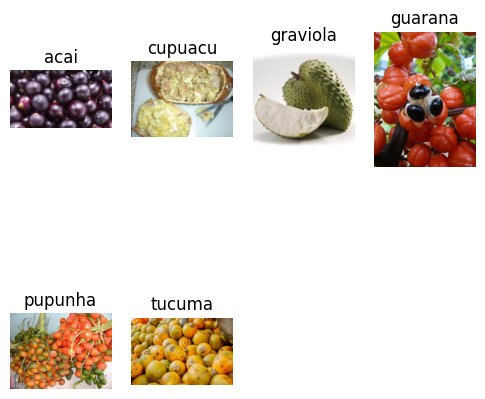

In [15]:
import random
import matplotlib.pyplot as plt
from PIL import Image

classes = sorted(os.listdir(train_dir))

plt.figure(figsize=(6,6))
#this is to display one random image from each class
for i, cls in enumerate(classes):
    class_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2, (len(classes)//2)+1, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

The dataset contains images grouped into class folders. Each folder represents a fruit category. The images vary in orientation, lighting, and background but share common visual features that help the CNN learn patterns.

In [16]:
from PIL import Image,UnidentifiedImageError

corrupted_images = [] #list to store all the corrupted images
#looping through each class folder and cheking for the corrupted images
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir,class_name)
    if os.path.isdir(class_path):  #ensuring it is a valid directory
      images = os.listdir(class_path)
      for file in os.listdir(class_path):
        image_path = os.path.join(class_path,file)
        try:
            with Image.open(image_path) as img:
              img.verify() #verifying if image can be opened correctly

        except (IOError, UnidentifiedImageError):

                corrupted_images.append(image_path)
                os.remove(image_path)
                print(f"Removed corrupted image: {image_path}")

if corrupted_images:
    print("Corrupted images found:")
    for img in corrupted_images:
        print(img)
else:
  print("No corrupted images found.")

No corrupted images found.


Checking class imbalance

In [17]:
#dictionary to store the number of images in each class
class_counts = {}

for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png','.jpg','jpeg'))]
    class_counts[class_name] = len(images) #counts images in each class

#printing class imbalance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid image count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("="* 45)


Class Distribution:
Class Name               Valid image count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


Random Image Selection

In [18]:
import random
selected_images = [] # Store image paths
selected_labels = [] # Store corresponding class names
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if images: # Ensure the class folder is not empty
      selected_img = os.path.join(class_path, random.choice(images))
      selected_images.append(selected_img)
      selected_labels.append(class_name)

Random image Plot


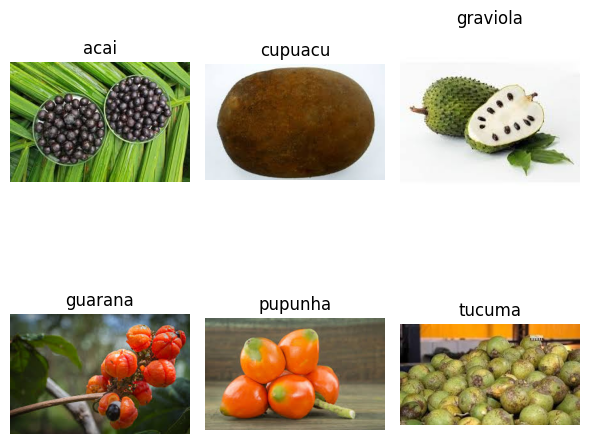

In [19]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# Determine grid size
num_classes = len(selected_images)
cols = (num_classes + 1) // 2 # Determine columns
rows = 2 # Fixed rows for layout
fig, axes = plt.subplots(rows, cols, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
  if i < num_classes:
    img = mpimg.imread(selected_images[i])
    ax.imshow(img)
    ax.set_title(selected_labels[i])
    ax.axis("off")
  else:
    ax.axis("off") # Hide empty subplots
plt.tight_layout()
plt.show()

Data loading and preprocessing

In [20]:
import tensorflow as tf

img_height = 224
img_width = 224
batch_size = 32
validation_split = 0.2

# normalizing pixel values from 0-255 to 0-1
# No longer applying rescale here, as it will be done in the model or checked manually
# rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height,img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)
#loading validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height,img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)
# Applying normalization to datasets once by mapping
train_ds = train_ds.map(lambda x, y: (x / 255.0, y))
val_ds = val_ds.map(lambda x, y: (x / 255.0, y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


Data Augmentation

In [21]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomContrast(factor=0.2)
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

CNN model Task 1

In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    # Removed Lambda layer, as normalization is now done in the dataset preprocessing
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Dense,
    GlobalAveragePooling2D
)

# Build CNN model
model = Sequential([
    # Input layer
    Input(shape=(224, 224, 3)),

    # Removed: Normalize pixel values from 0-255 to 0-1 (now done in train_ds/val_ds)
    # Lambda(lambda x: x / 255.0),

    # 1st convolution block
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # 2nd convolution block
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # 3rd convolution block
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.30),

    # 4th convolution block
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.30),

    # Reduce feature maps to one value per channel
    GlobalAveragePooling2D(),

    # Fully connected layer
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    # Output layer
    Dense(len(class_names), activation='softmax')
])

In [23]:
for images, labels in val_ds.take(1):
    print('Min pixel value:', images.numpy().min())
    print('Max pixel value:', images.numpy().max())
    print('Sample labels (first 10):', labels[:10].numpy())

print('\nDataset class names:', class_names)

Min pixel value: 0.0
Max pixel value: 1.0
Sample labels (first 10): [4 4 4 5 5 5 5 5 5 5]

Dataset class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [24]:
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,518 (1.62 MB)

 Trainable params: 423,302 (1.61 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [25]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [26]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Save the best model during training
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Stop training if validation loss does not improve
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1030 - loss: 3.1571
Epoch 1: val_loss improved from None to 1.83985, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.1528 - loss: 2.7726 - val_accuracy: 0.0000e+00 - val_loss: 1.8398
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3808 - loss: 1.6483
Epoch 2: val_loss did not improve from 1.83985
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step - accuracy: 0.3611 - loss: 1.7267 - val_accuracy: 0.0000e+00 - val_loss: 1.8429
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4907 - loss: 1.6712
Epoch 3: val_loss improved from 1.83985 to 1.79886, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.4722 - loss: 1.7485 - val_accuracy: 0.0000e+00 - val_loss: 1.7989
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5758 - loss: 1.2485
Epoch 4

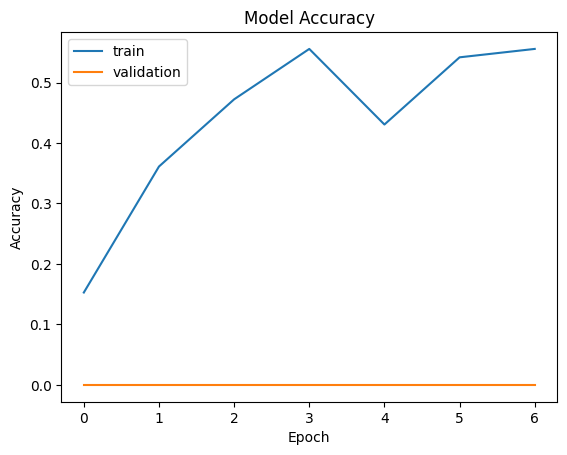

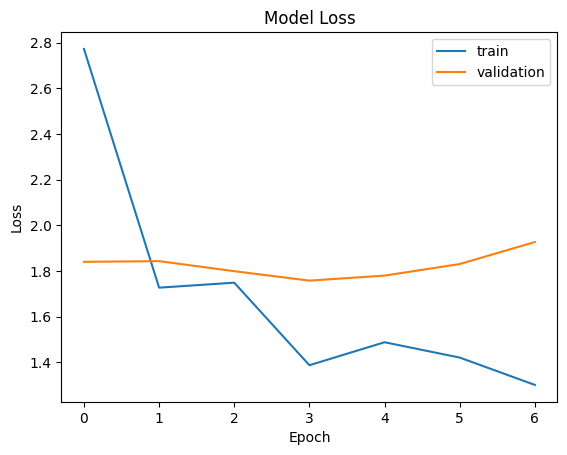

In [27]:
plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'],label='validation')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='validation')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

#Key observations:

Training improving,
Validation stuck,
Accuracy very low (~17%),
Loss not decreasing

In [28]:
test_loss,test_acc = model.evaluate(val_ds)

print("Test Accuracy:",test_acc)
print("Test Loss:",test_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 801ms/step - accuracy: 0.0000e+00 - loss: 1.7575
Test Accuracy: 0.0
Test Loss: 1.7575026750564575


In [29]:
# Save the trained model
model.save("fruit_cnn_model.keras")

# Load the saved model
from tensorflow.keras.models import load_model
loaded_model = load_model("fruit_cnn_model.keras", safe_mode=False)

# Evaluate the loaded model
loss, accuracy = loaded_model.evaluate(val_ds)

print("Loaded Model Accuracy:", accuracy)
print("Loaded Model Loss:", loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 873ms/step - accuracy: 0.0000e+00 - loss: 1.7575
Loaded Model Accuracy: 0.0
Loaded Model Loss: 1.7575026750564575


In [30]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images,labels in val_ds:

    predictions = loaded_model.predict(images)

    pred_labels = np.argmax(predictions,axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)
unique_labels = np.unique(y_true)

print(classification_report(y_true,y_pred, labels=unique_labels,target_names=[classes[i] for i in unique_labels]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 626ms/step
              precision    recall  f1-score   support

     pupunha       0.00      0.00      0.00       3.0
      tucuma       0.00      0.00      0.00      15.0

   micro avg       0.00      0.00      0.00      18.0
   macro avg       0.00      0.00      0.00      18.0
weighted avg       0.00      0.00      0.00      18.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

# Transfer Learning (VGG16)

In [31]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

Load Pretrained VGG16 Model

In [32]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Freeze pretrained layers

In [33]:
for layer in base_model.layers:
    layer.trainable = False

Build Transfer Learning Model

In [34]:
model_transfer = Sequential([

    base_model,

    Flatten(),

    Dense(256, activation='relu'),

    Dense(len(class_names), activation='softmax')
])

Compile the Model

In [35]:
model_transfer.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train the Model

In [36]:
history_transfer = model_transfer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 39s 13s/step - accuracy: 0.0694 - loss: 9.1940 - val_accuracy: 0.0000e+00 - val_loss: 12.1929
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 38s 13s/step - accuracy: 0.3194 - loss: 4.1407 - val_accuracy: 0.5556 - val_loss: 1.8606
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 35s 11s/step - accuracy: 0.6389 - loss: 1.6398 - val_accuracy: 0.8333 - val_loss: 1.0361
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 40s 11s/step - accuracy: 0.6250 - loss: 1.1739 - val_accuracy: 0.8889 - val_loss: 0.4826
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 35s 11s/step - accuracy: 0.9028 - loss: 0.2569 - val_accuracy: 0.2778 - val_loss: 2.6862
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 35s 11s/step - accuracy: 0.8611 - loss: 0.4886 - val_accuracy: 0.5000 - val_loss: 2.0198
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 34s 11s/step - accuracy: 0.9167 - loss: 0.2485 - val_accuracy: 0.9444 - val_loss: 0.4957
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 35s 11s/step - accuracy: 0.9861 - loss: 0.0366 - val_accuracy: 0.8889 - val_loss: 0.

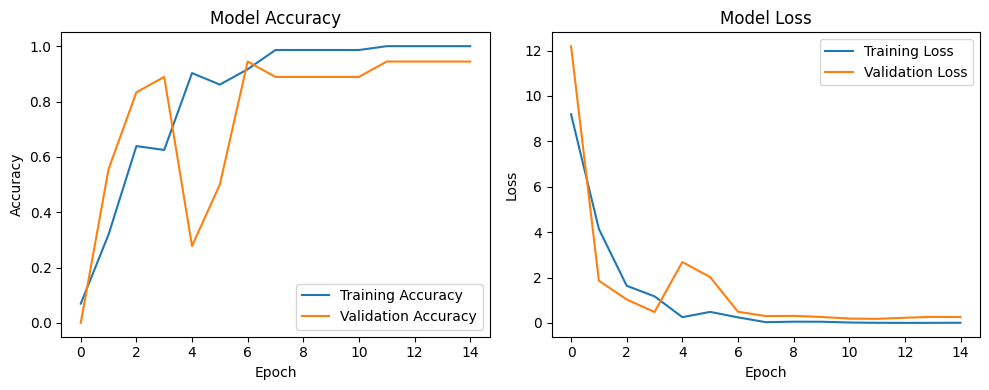

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Accuracy graph
plt.subplot(1,2,1)
plt.plot(history_transfer.history['accuracy'], label='Training Accuracy')
plt.plot(history_transfer.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss graph
plt.subplot(1,2,2)
plt.plot(history_transfer.history['loss'], label='Training Loss')
plt.plot(history_transfer.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

Evaluate the Model

In [38]:
loss, accuracy = model_transfer.evaluate(val_ds)

print("Transfer Learning Accuracy:", accuracy)
print("Transfer Learning Loss:", loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.9444 - loss: 0.2603
Transfer Learning Accuracy: 0.9444444179534912
Transfer Learning Loss: 0.2602739632129669


In [39]:
model_transfer.save("final_model.keras")

# Fine-Tuning

In [40]:
base_model.trainable = True

# Unfreeze the last 10 layers for fine-tuning
for layer in base_model.layers[:-10]:
    layer.trainable = False
for layer in base_model.layers[-10:]:
    layer.trainable = True

Recompile with smaller learning rate

In [41]:
from tensorflow.keras.optimizers import Adam

model_transfer.compile(
    optimizer=Adam(learning_rate=1e-5), # Use Adam with a very low learning rate
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train Fine-Tuned Model

In [ ]:
history_finetune = model_transfer.fit(
    train_ds.map(lambda x, y: (data_augmentation(x, training=True), y)), # Apply data augmentation
    validation_data=val_ds,
    epochs=15, # Increased epochs slightly, early stopping will manage training duration
    callbacks=[early_stop] # Use early stopping
)

Epoch 1/15


Final Evaluation

In [ ]:
loss, accuracy = model_transfer.evaluate(val_ds)

print("Fine-Tuned Model Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.9444 - loss: 0.1977
Fine-Tuned Model Accuracy: 0.9444444179534912
